In [ ]:
import anndata as ad
import pandas as pd
from itertools import combinations
import numpy as np

# Number of cores to use
ncores = 64

import sys

import anndata
#from netmap.downstream import final_downstream
from netmap.downstream.edge_selection import *
from netmap.downstream.clustering import *
#from netmap.downstream.final_downstream import *
from netmap.downstream.plotting import *

from netmap.downstream.regulon import *
import warnings

from netmap.utils.data_utils import *
from netmap.utils.tf_utils import *
from netmap.utils.netmap_config import NetmapConfig

from netmap.model.train_model import create_model_zoo
from netmap.grn.inferrence import inferrence, inferrence_model_wise
from netmap.masking.internal import *
from netmap.masking.external import *


import scipy.sparse as scs


import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

import yaml


def save_clustering_score_to_yaml(analysis_output_dir, score):
    data = {'clustering_score': float(score) }
    with open(op.join(analysis_output_dir, 'clustering_score.yaml'), 'w') as file:
        yaml.dump(data, file, default_flow_style=False)

In [2]:
collectri = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/input_network/collectri.tsv', sep = '\t')
adata_raw = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/bd-rhap-rep2.h5ad')
experiment_name = 'bd-rhap-rep2-X'
output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/{experiment_name}"
# This is where the GRN files are stored.
output_dir_grn = Path(op.join(output_dir, "grn"))
var = pd.read_csv(op.join(output_dir, f'{experiment_name}_var.tsv'))
obs = pd.read_csv(op.join(output_dir, f'{experiment_name}_obs.tsv'))
grn_adata = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)


In [3]:
analysis_output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/{experiment_name}"

In [4]:
os.makedirs(analysis_output_dir, exist_ok=True)

In [5]:
adata_raw.obs['celltype_semi_manual'].value_counts()

celltype_semi_manual
cd14+_monocytes    8896
cd14-_monocytes    1941
cd4+_tcells        1670
nk_cells            922
DC                  534
cd8+_tcells         532
b_cells             297
pDC                 241
Name: count, dtype: int64

In [6]:
grn_adata = retrieve_top_edges(grn_adata, output_dir_grn, percentage=0.1 )

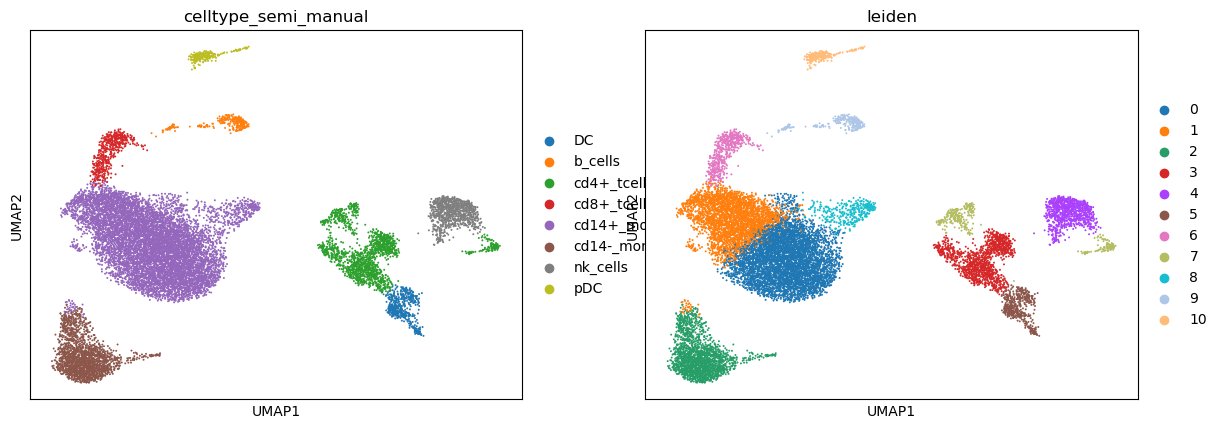

In [7]:
with plt.rc_context(): 
    sc.pl.umap(adata_raw, color = ['celltype_semi_manual', 'leiden'], show=False)
    plt.savefig(op.join(analysis_output_dir, 'gex_clustering_annotation_umap.pdf'), bbox_inches="tight")



In [8]:
grn_adata.var = grn_adata.var.set_index('index')



In [9]:
sc.tl.pca(grn_adata, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(grn_adata, n_neighbors = 50)
sc.tl.umap(grn_adata, n_components =50)


In [10]:
sc.tl.tsne(grn_adata)

In [11]:
sc.tl.leiden(grn_adata, resolution=0.18)

In [12]:
with plt.rc_context(): 
    sc.pl.tsne(grn_adata, color = ['leiden', 'celltype_semi_manual'], show=False)
    plt.savefig(op.join(analysis_output_dir, 'grn_clustering_comparison_tsne.pdf'), bbox_inches="tight")

In [13]:
print("\nClustering Score Evaluation")
for col_grn in ["leiden"]:
    score = unify_group_labelling( adata_raw, grn_adata, 'celltype_semi_manual', col_grn)
    print(f"{col_grn} score: {score}")
save_clustering_score_to_yaml(analysis_output_dir, score)


Clustering Score Evaluation
leiden score: 0.9291558571143484


In [14]:
adata_raw.obs['celltype_remapped'] = grn_adata.obs['leiden_remap'].values


In [15]:
grn_adata2 = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)
grn_adata2.var = grn_adata2.var.set_index('index')

In [16]:
grn_adata2.obs = grn_adata.obs

In [17]:
add_neighbourhood_expression_mask(adata_raw, grn_adata2, strict=False, layer = 'counts' )
grn_adata2 = add_cluster_based_candidate_edges(grn_adata2, threshold=0.5)


In [18]:
index_list = np.where(grn_adata2.var['candidate_edge'])[0]
grn_adata3 = retrieve_edges_by_index(grn_adata2, output_dir_grn, index_list)

In [19]:
grn_adata3.obs = grn_adata2.obs
grn_adata3.obsm['X_pca'] = grn_adata.obsm['X_pca']
grn_adata3.obsm['X_umap'] = grn_adata.obsm['X_umap']

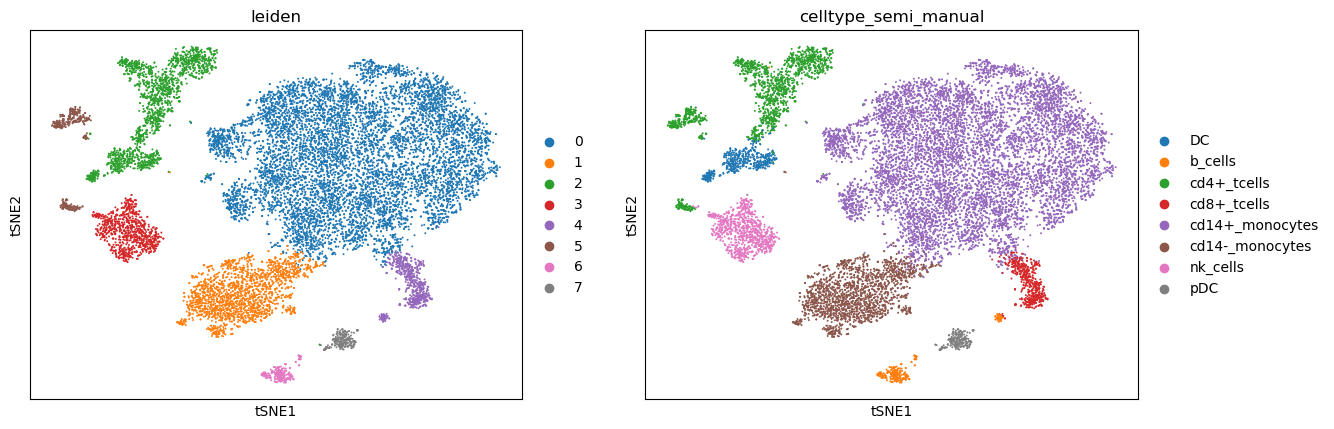

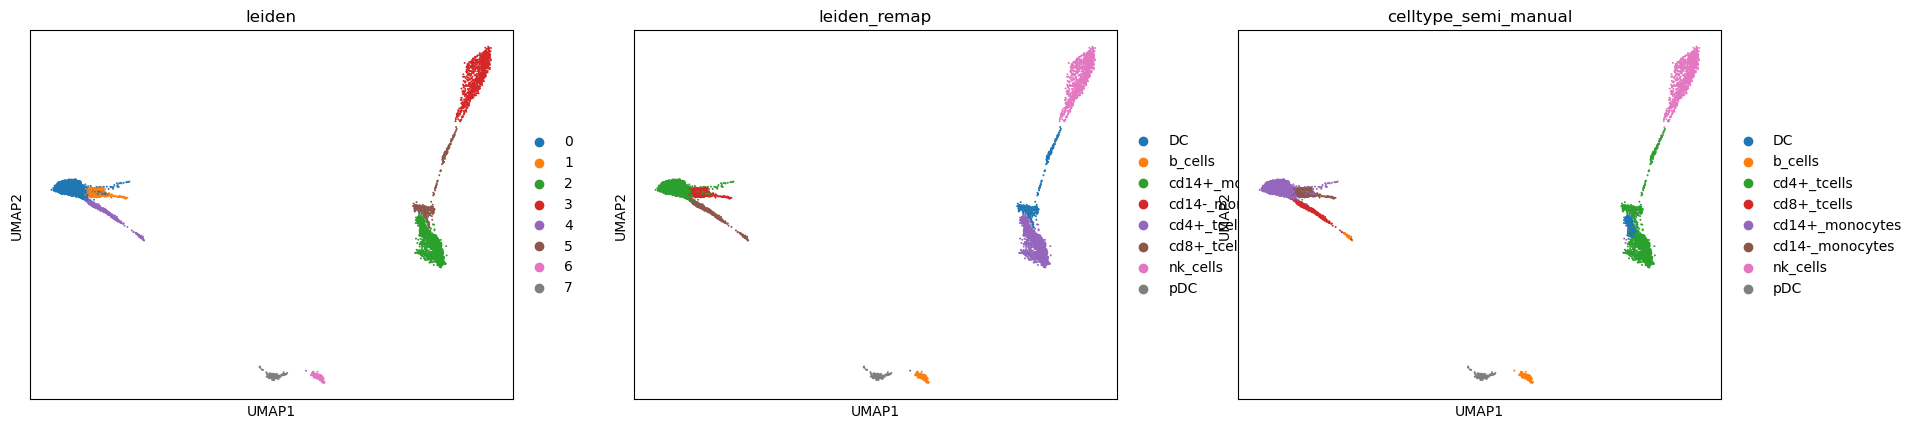

In [20]:
sc.pl.umap(grn_adata3, color = ['leiden', 'leiden_remap', 'celltype_semi_manual'])

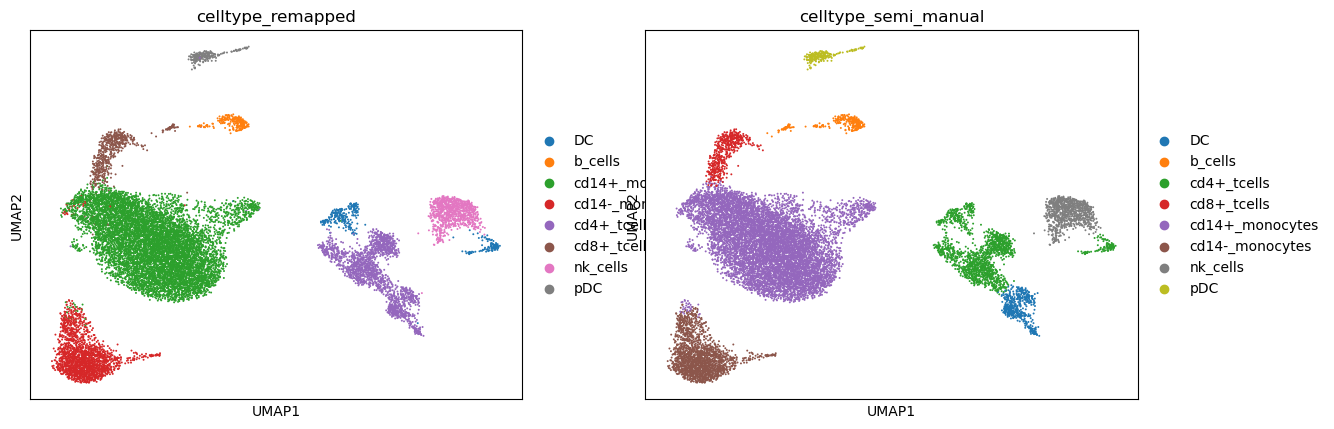

In [21]:
sc.pl.umap(adata_raw, color = ['celltype_remapped', 'celltype_semi_manual' ])

In [22]:
cross_tab = pd.crosstab(grn_adata3.obs['celltype_semi_manual'], grn_adata3.obs['leiden_remap'])

In [51]:
grn_adata3 = add_external_grn(grn_ad=grn_adata3,external_grn=collectri,name_grn='collectri')

In [24]:
# Identify top targets for each source gene within clusters
# - Keeps up to top_per_source strongest targets
# - Removes regulons smaller than min_reg_size
cluster_column = 'celltype_semi_manual'
top_per_source = 30
min_reg_size = 3
add_neighbourhood_expression_mask(adata_raw, grn_adata3, strict=False, layer = 'counts' )



AnnData object with n_obs × n_vars = 15033 × 232260
    obs: 'Unnamed: 0', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'predicted_labels', 'majority_voting', 'conf_score', 'granular', 'leiden', 'celltype_semi_manual', 'leiden_remap'
    var: 'source', 'target', 'edge_sums', 'edge_means', 'count_nonzero', 'count_nonzero_norm', 'cd14+_monocytes_nonzero', 'cd14+_monocytes_candidate_edge', 'cd14-_monocytes_nonzero', 'cd14-_monocytes_candidate_edge', 'cd4+_tcells_nonzero', 'cd4+_tcells_candidate_edge', 'nk_cells_nonzero', 'nk_cells_candidate_edge', 'cd8+_tcells_nonzero', 'cd8+_tcells_candidate_e

In [58]:
grn_adata3 = add_external_grn(grn_ad=grn_adata3,external_grn=collectri,name_grn='collectri')
keep_edges = select_top_edges(gene_inter_adata=grn_adata3, adata=adata_raw, top_per_source=top_per_source, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True, min_edge_support= 0.5)


Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets for cluster: cd4+_tcells
Selecting targets for cluster: cd8+_tcells
Selecting targets for cluster: nk_cells
Selecting targets for cluster: pDC


In [26]:
all_regulons = make_cluster_regulon_dataframe(keep_edges)
all_regulons.to_csv(op.join(analysis_output_dir, 'regulons.tsv'), sep = '\t')

In [93]:
forgeign_analysis_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep1-X"
foreign_regulons = pd.read_csv(op.join(forgeign_analysis_dir, 'regulons.tsv'), sep = '\t', index_col=0)

In [94]:
foreign_regulons_el = load_edge_dict_from_dataframe(foreign_regulons)

In [95]:
foreign_regulons_el

{'all': {'DC': {'edges':       source   target  sum_of_edge
   0      ACAP1   FCER1A     0.007293
   1      ACAP1  SLC38A1     0.005480
   2      ACAP1      CD2     0.004546
   3      ACAP1     SELL     0.004062
   4      ACAP1    ITM2C     0.003640
   ...      ...      ...          ...
   10645   WDR7     CPVL     0.001122
   10646   WDR7   CAMK1D     0.001115
   10647   WDR7    PARP8     0.001109
   10648   WDR7     CD36     0.001092
   10649   WDR7    PLBD1     0.001089
   
   [10650 rows x 3 columns]},
  'b_cells': {'edges':                source   target  sum_of_edge
   0              ABLIM1      LTB     0.010368
   1              ABLIM1     FCMR     0.010303
   2              ABLIM1    TRBC2     0.010297
   3              ABLIM1     ETS1     0.009833
   4              ABLIM1    BANK1     0.009414
   ...               ...      ...          ...
   6745  ENSG00000293488     TLN1     0.000679
   6746  ENSG00000293488     BTG2     0.000602
   6747  ENSG00000293488  ST6GAL1     0.00052

In [99]:
import pandas as pd
import numpy as np

def aggregate_edges_accept_missing(selected_edges, grn_adata, key='unique') -> (pd.DataFrame, pd.DataFrame):
    """
    Computes mean GRN activity and returns a status DataFrame of edge counts.

    Returns
    -------
    regulons_df : pd.DataFrame
        DataFrame with mean activity scores.
    stats_df : pd.DataFrame
        DataFrame containing counts of valid and missing edges per regulon.
    """
    regulons = {}
    stats_list = []
    
    # Pre-fetch available edges for O(1) lookup speed
    available_edges = set(grn_adata.var_names)

    for ct in selected_edges[key]:
        edge_groups = selected_edges[key][ct]['edges'].groupby('source')
        
        for g, group in edge_groups:
            regulon_name = f"{ct}_{g}"
            
            # Construct the expected edge strings
            edge_list = (group['source'] + "_" + group['target']).tolist()
            total_count = len(edge_list)
            
            # Identify which exist in the data
            valid_edges = [e for e in edge_list if e in available_edges]
            valid_count = len(valid_edges)
            missing_count = total_count - valid_count
            
            # Store statistics
            stats_list.append({
                'regulon': regulon_name,
                'cluster': ct,
                'source_gene': g,
                'valid_edges': valid_count,
                'missing_edges': missing_count,
                'total_expected': total_count
            })
            
            # Only calculate activity if we have at least one valid edge
            if valid_count > 0:
                # Ensure we handle sparse or dense matrices correctly
                mean_activity = grn_adata[:, valid_edges].X.mean(axis=1)
                regulons[regulon_name] = np.ravel(mean_activity)
            else:
                # Optional: fill with zeros or NaNs if a regulon is entirely missing
                regulons[regulon_name] = np.zeros(grn_adata.n_obs)

    regulons_df = pd.DataFrame(regulons, index=grn_adata.obs_names)
    stats_df = pd.DataFrame(stats_list)
    
    return regulons_df, stats_df

In [148]:
stat_df

,regulon,cluster,source_gene,valid_edges,missing_edges,total_expected
0,DC_AAK1,DC,AAK1,11,3,14
1,DC_ACAP1,DC,ACAP1,13,3,16
2,DC_ACBD6,DC,ACBD6,0,30,30
3,DC_ACTN1,DC,ACTN1,9,4,13
4,DC_ACYP2,DC,ACYP2,23,7,30
...,...,...,...,...,...,...
2163,pDC_ZFAND3,pDC,ZFAND3,10,4,14
2164,pDC_ZFAT,pDC,ZFAT,23,7,30
2165,pDC_ZNF767P--chr7:149547154(-),pDC,ZNF767P--chr7:149547154(-),0,30,30
2166,pDC_ZNF91,pDC,ZNF91,0,16,16


In [149]:
import scanpy as sc
import pandas as pd

def merge_regulon_stats_with_ranking(stats_df, all_signatures, cluster_column, method='wilcoxon'):
    """
    Merges edge statistics with Scanpy results and adds a group-wise rank.
    """
    # 1. Get the rank_genes_groups dataframe
    bcrank_internal = sc.get.rank_genes_groups_df(
        all_signatures, 
        group=all_signatures.obs[cluster_column].unique().tolist(), 
        key=method
    )

    # 2. Merge with your edge stats
    merged_df = pd.merge(
        bcrank_internal, 
        stats_df, 
        left_on='names', 
        right_on = 'regulon',
        how='left'
    )

    # 3. Add a group-wise rank
    # We rank by 'pvals_adj' (smallest is rank 1) or 'scores' (highest is rank 1)
    # Using method='min' handles ties, while 'first' gives a unique rank to every row
    merged_df['group_rank'] = (
        merged_df.groupby('group')['pvals_adj']
        .rank(method='first', ascending=True)
        .astype(int)
    )

    # Optional: Sort the dataframe by group and then rank for readability
    merged_df = merged_df.sort_values(['group', 'group_rank'])
    
    return merged_df

In [165]:
regulon_df, stat_df = aggregate_edges_accept_missing(foreign_regulons_el, grn_adata3, key='unique')
final_report = merge_regulon_stats_with_ranking(stat_df, all_signatures, 'leiden_remap')
final_report['set_type'] = 'unique'

regulon_df, stat_df = aggregate_edges_accept_missing(foreign_regulons_el, grn_adata3, key='all')
final_report2 = merge_regulon_stats_with_ranking(stat_df, all_signatures, 'leiden_remap')
final_report2['set_type'] = 'all'

final_report = pd.concat([final_report, final_report2])

final_report['percentage_recovered'] = final_report['valid_edges']/final_report['total_expected']


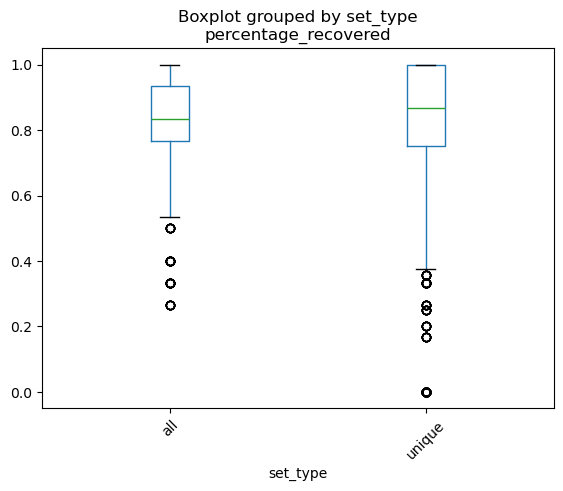

In [164]:

final_report.boxplot(column='percentage_recovered', by='set_type', grid=False, rot=45)
plt.show()

In [ ]:
regus = aggregate_edges(foreign_regulons_el, grn_adata3, key='unique')



all_signatures = ad.AnnData(X = regus, obs = adata_raw.obs, obsm = adata_raw.obsm)
all_signatures.obs['leiden_remap'] = grn_adata3.obs['leiden_remap'].values
sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")
bcrank_internal = sc.get.rank_genes_groups_df(all_signatures, group = all_signatures.obs[cluster_column].unique(), key  = 'wilcoxon')

DC


KeyError: "Values [np.str_('AAK1_IRF1'), np.str_('AAK1_MEGF9'), np.str_('AAK1_HMGB2')], from [np.str_('AAK1_S100A9'), np.str_('AAK1_CSF3R'), np.str_('AAK1_PLBD1'), np.str_('AAK1_VCAN'), np.str_('AAK1_GPRIN3'), np.str_('AAK1_AOAH'), np.str_('AAK1_IRF1'), np.str_('AAK1_MNDA'), np.str_('AAK1_LIMS1'), np.str_('AAK1_ZEB2'), np.str_('AAK1_MEGF9'), np.str_('AAK1_FCN1'), np.str_('AAK1_HMGB2'), np.str_('AAK1_S100A8')], are not valid obs/ var names or indices."

In [80]:
regus = aggregate_edges(keep_edges, grn_adata3, key='unique')
all_signatures = ad.AnnData(X = regus, obs = adata_raw.obs, obsm = adata_raw.obsm)
all_signatures.obs['leiden_remap'] = grn_adata3.obs['leiden_remap'].values
sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")
bcrank_foreign = sc.get.rank_genes_groups_df(all_signatures, group = all_signatures.obs[cluster_column].unique(), key  = 'wilcoxon')

DC
b_cells
cd14+_monocytes
cd14-_monocytes
cd4+_tcells
cd8+_tcells
nk_cells
pDC


In [83]:
bcrank_internal[0:20]

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,DC,DC_CCL5,37.856007,4.049083,0.000000e+00,0.000000e+00
1,DC,DC_CD74,37.709534,NaN,0.000000e+00,0.000000e+00
2,DC,DC_CD3E,37.131851,3.494564,8.606194e-302,5.447721e-299
3,DC,DC_CST7,36.957561,3.800503,5.506408e-299,2.614167e-296
4,DC,DC_ZFP36,36.410480,NaN,2.905920e-290,1.103668e-287
5,DC,nk_cells_CCL5,36.124985,3.589411,9.193685e-286,2.909801e-283
6,DC,DC_CD3D,35.957829,2.996562,3.818813e-283,1.035989e-280
7,DC,DC_CD3G,35.069077,4.620450,1.996479e-269,4.739142e-267
8,DC,DC_ARL4C,34.825932,2.449156,9.853990e-266,1.922738e-263
9,DC,nk_cells_IKZF3,34.822418,2.867379,1.113750e-265,1.922738e-263


In [84]:
bcrank_foreign[0:20]

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,DC,DC_CCL5,37.856007,4.049083,0.000000e+00,0.000000e+00
1,DC,DC_CD74,37.709534,NaN,0.000000e+00,0.000000e+00
2,DC,DC_CD3E,37.131851,3.494564,8.606194e-302,5.447721e-299
3,DC,DC_CST7,36.957561,3.800503,5.506408e-299,2.614167e-296
4,DC,DC_ZFP36,36.410480,NaN,2.905920e-290,1.103668e-287
5,DC,nk_cells_CCL5,36.124985,3.589411,9.193685e-286,2.909801e-283
6,DC,DC_CD3D,35.957829,2.996562,3.818813e-283,1.035989e-280
7,DC,DC_CD3G,35.069077,4.620450,1.996479e-269,4.739142e-267
8,DC,DC_ARL4C,34.825932,2.449156,9.853990e-266,1.922738e-263
9,DC,nk_cells_IKZF3,34.822418,2.867379,1.113750e-265,1.922738e-263


In [49]:
# grn_adata3.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_processed.h5ad'))
# all_signatures.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_signatures.h5ad'))

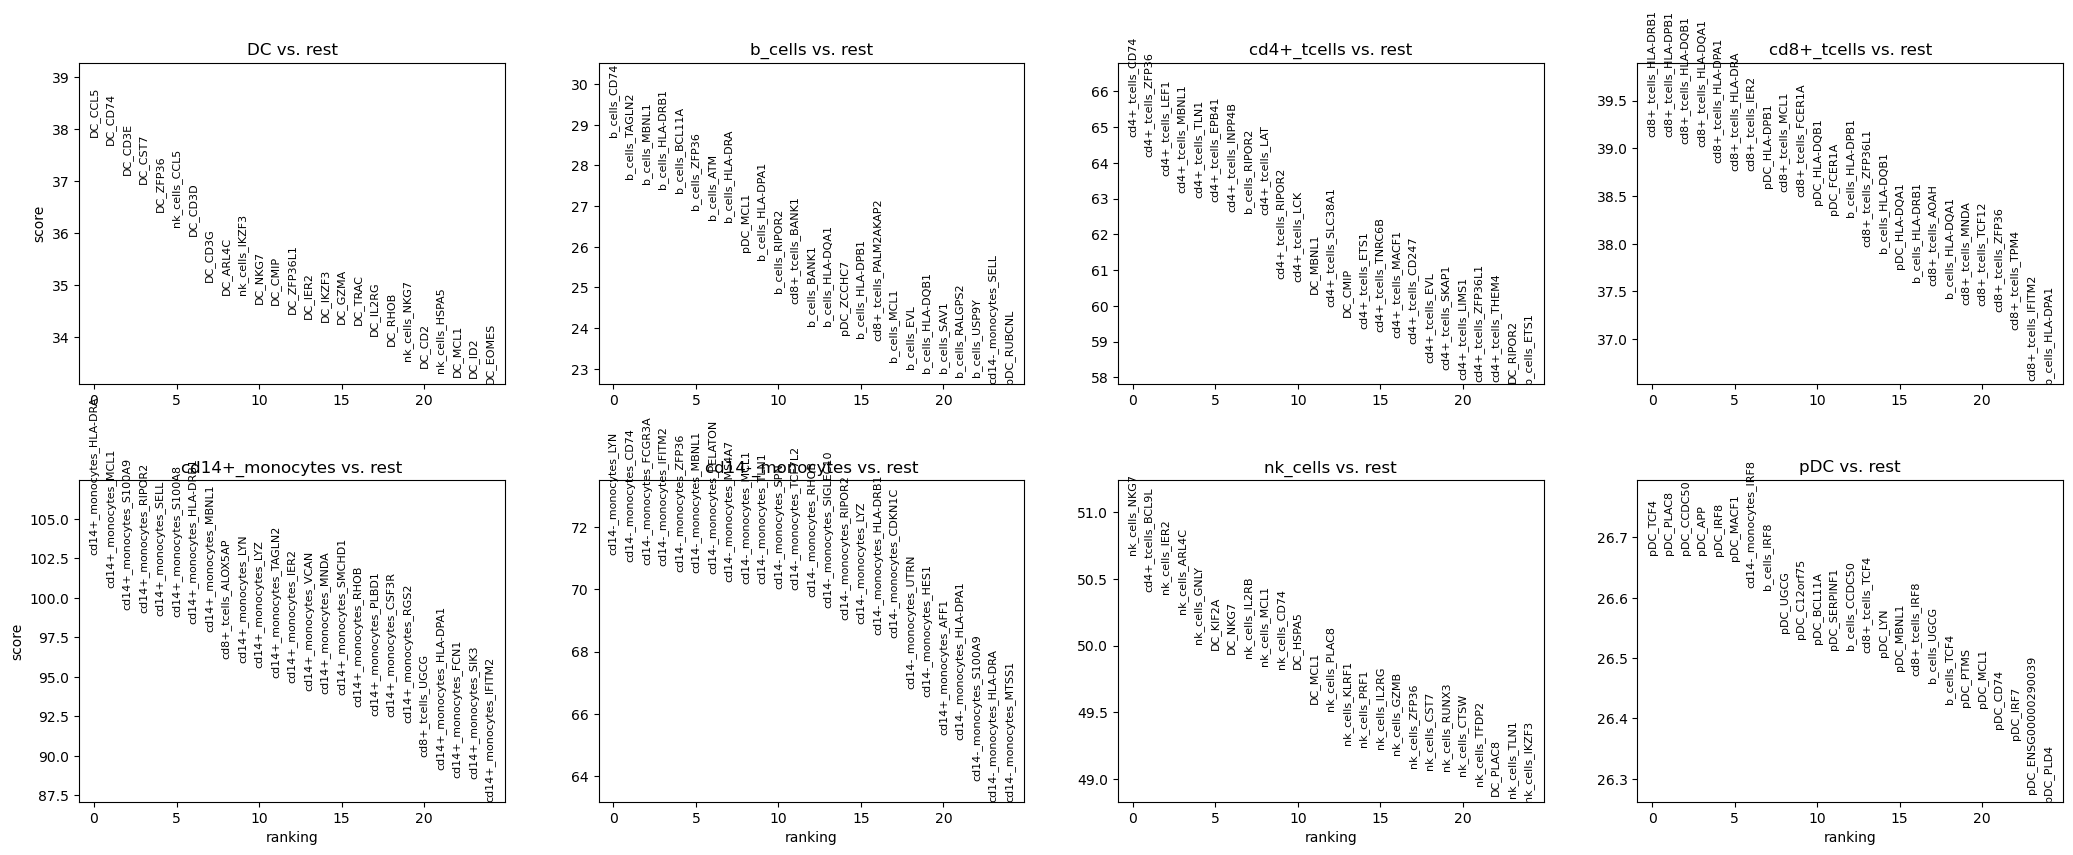

In [ ]:
# Compute differential regulon activity using the nonparametric Wilcoxon test.
# This identifies regulons whose activity significantly differs between clusters.

# Visualize the top differentially active regulons per cluster.
# The plot shows effect sizes and significance for the highest-ranked regulons.
sc.pl.rank_genes_groups(all_signatures, n_genes=25, sharey=False, key="wilcoxon")

In [70]:
pp = rank_regulon_groups_dotplot(grn_adata3, adata_regl=all_signatures, return_fig=True, new_cluster_column=cluster_column, n_genes=10)

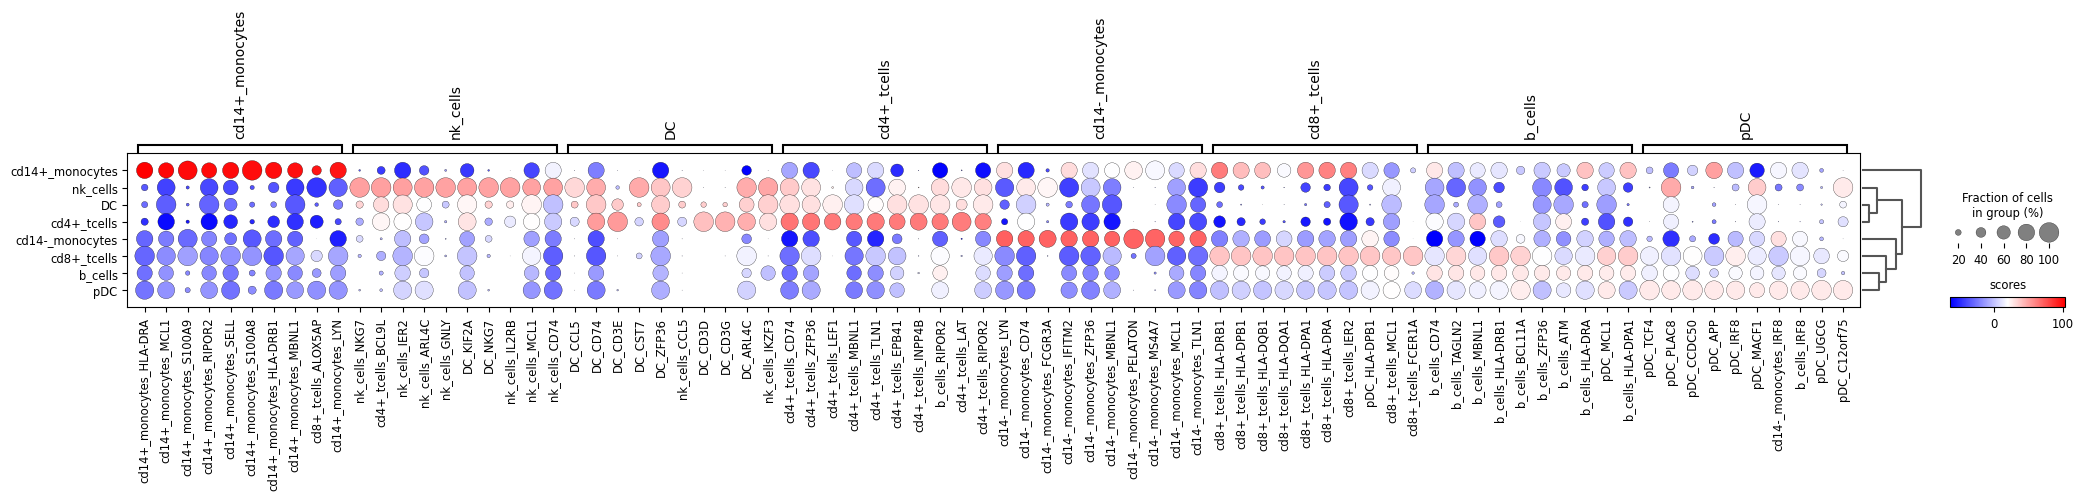

In [71]:
pp.show()

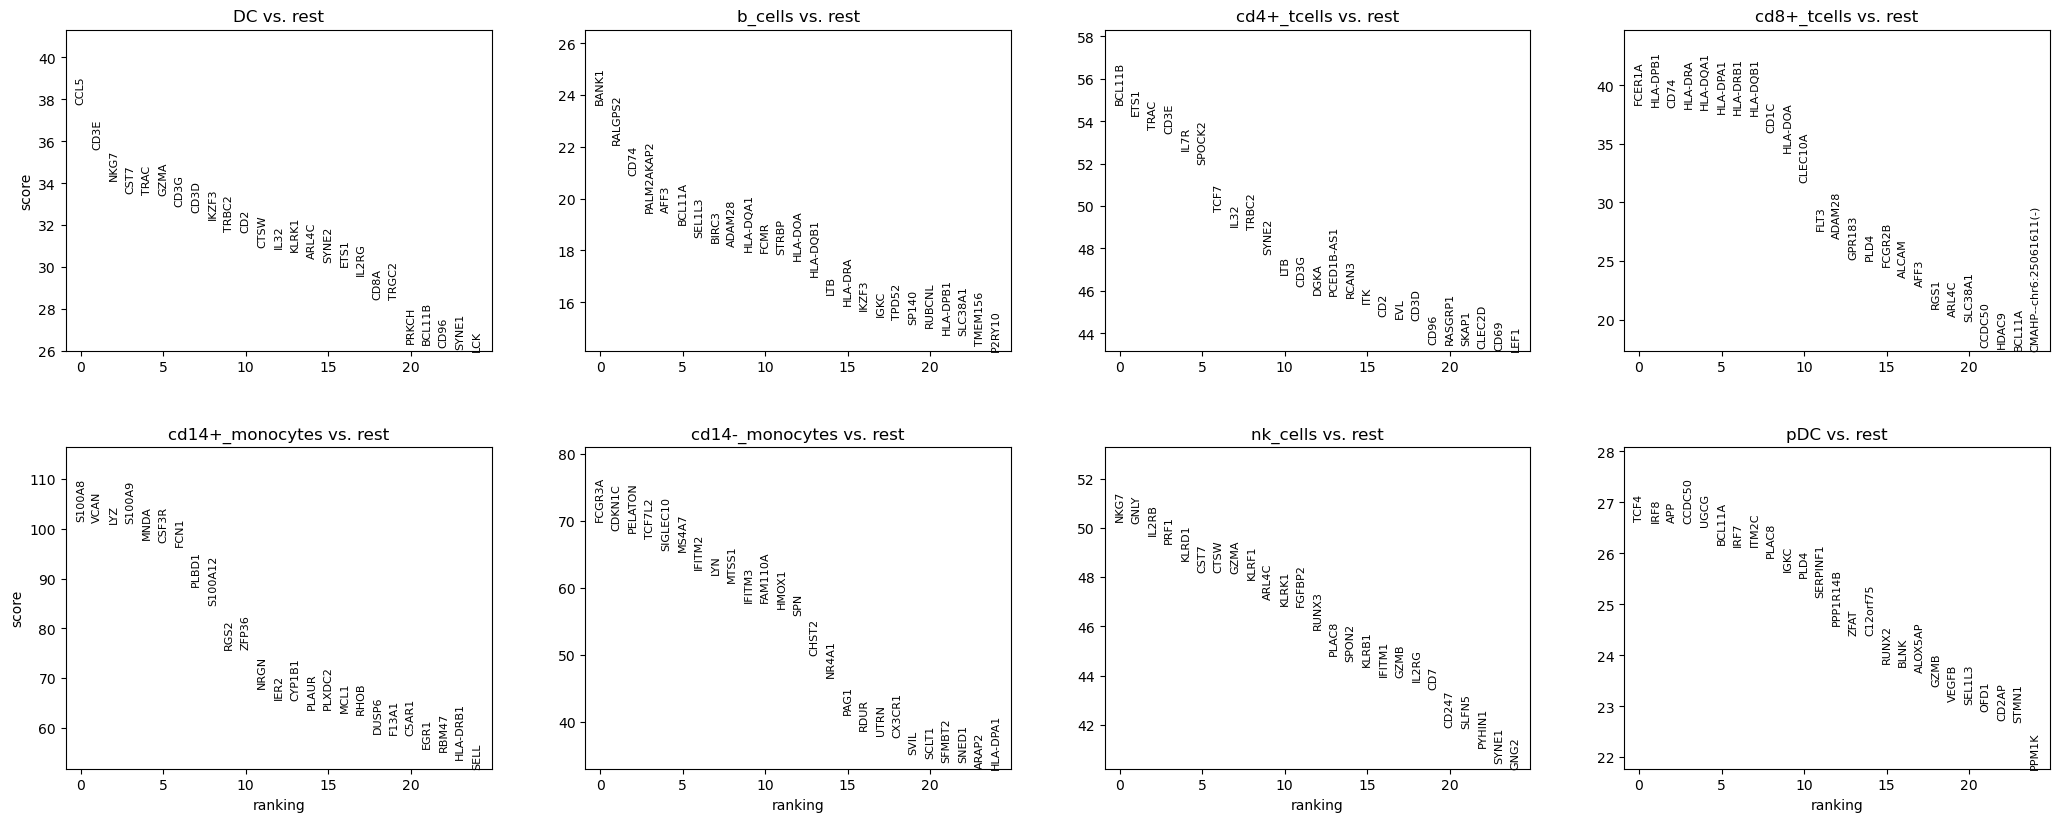

In [72]:
# Compute differential regulon activity using the nonparametric Wilcoxon test.
# This identifies regulons whose activity significantly differs between clusters.
sc.tl.rank_genes_groups(adata_raw, cluster_column, method='wilcoxon', key_added = "wilcoxon")

# Visualize the top differentially active regulons per cluster.
# The plot shows effect sizes and significance for the highest-ranked regulons.
sc.pl.rank_genes_groups(adata_raw, n_genes=25, sharey=False, key="wilcoxon")

In [76]:
bcrank = sc.get.rank_genes_groups_df(all_signatures, group = all_signatures.obs[cluster_column].unique(), key  = 'wilcoxon')

In [77]:
bcrank

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,DC,DC_CCL5,37.856007,4.049083,0.000000e+00,0.000000e+00
1,DC,DC_CD74,37.709534,NaN,0.000000e+00,0.000000e+00
2,DC,DC_CD3E,37.131851,3.494564,8.606194e-302,5.447721e-299
3,DC,DC_CST7,36.957561,3.800503,5.506408e-299,2.614167e-296
4,DC,DC_ZFP36,36.410480,NaN,2.905920e-290,1.103668e-287
...,...,...,...,...,...,...
15187,pDC,DC_FOSB,-25.401693,NaN,2.415589e-142,8.994518e-141
15188,pDC,nk_cells_CD74,-25.565289,2.279281,3.712610e-144,1.468801e-142
15189,pDC,cd14+_monocytes_SELL,-25.732130,NaN,5.109644e-146,2.205276e-144
15190,pDC,cd4+_tcells_ENSG00000290039,-25.926535,NaN,3.344927e-148,1.588004e-146


In [ ]:
bcrank_entropy(bcrank, top_n=150, title="Term entropy", figsize=(6,4))

NameError: name 'bcrank' is not defined